# Demo 03: Distillation Pipeline — Teacher → Student

**Block 5** | Day 1 | 25 minutes

This notebook demonstrates the **knowledge distillation** pipeline: a large foundation
model (the teacher) auto-labels images, and a small specialized model (the student)
trains on those labels. The teacher retires. The student deploys.

We use **SAM3** (Segment Anything Model 3, via HuggingFace Transformers) as the teacher
and **YOLO26n** (2.4M parameters) as the student.

**Domain:** Milk bottles and caps — a clean toy problem that shows the pipeline end-to-end.
Tomorrow (Day 2), you apply the same pipeline to YOUR domain.

---
## The Distillation Concept



The bridge between them is **auto-labeling**. The teacher looks at your images, draws
bounding boxes, writes YOLO-format label files. The student trains on those labels.
The teacher retires.

The student doesn't know it was taught by a machine. The label format is identical to
human annotations. Same  files, same bounding box coordinates.

---
## Why Not Deploy the Teacher?

| Metric | Teacher (SAM3) | Student (YOLO26n) | Difference |
|--------|:--------------:|:-----------------:|:----------:|
| **Parameters** | 2.9B | 2.4M | 1200x smaller |
| **Inference (T4)** | ~200 ms | 1.7 ms | ~100x faster |
| **Inference (Jetson)** | Doesn't fit | ~11 ms (90 FPS) | Edge-capable |
| **Weights size** | ~5 GB | 5.5 MB | Fits on microcontroller |
| **Vocabulary** | Open (any text prompt) | Fixed (trained classes only) | Flexibility vs speed |

**The teacher's job is to teach, not to deploy.**

In [7]:
# ── Cell 3: Environment setup ─────────────────────────────────────────────────
import torch
import sys
import os
import time
from pathlib import Path

# Device detection: CUDA > MPS > CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Python:  {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_mem
    if hasattr(torch.cuda.get_device_properties(0), 'total_memory'):
        mem = torch.cuda.get_device_properties(0).total_memory
    print(f"VRAM:    {mem / 1e9:.1f} GB")

# ── Working directory ────────────────────────────────────────────────────────
HOME = Path(".").resolve().parent
DATA_DIR = HOME / "data"
DATA_DIR.mkdir(exist_ok=True)
print(f"Home: {HOME}")

Python:  3.10.18 (main, Aug 28 2025, 17:00:20) [Clang 20.1.4 ]
PyTorch: 2.10.0
Device:  mps
Home: /Users/dejandukic/dejan_dev/ai-factory/cv-workshop-hpc


---
## Step 1: Prepare Image Dataset

We start with raw videos of milk bottles on a conveyor belt. The pipeline:
1. Download videos
2. Extract every 10th frame
3. Split into train/test sets

This gives us ~150 unlabeled images — exactly the starting point for auto-labeling.

In [8]:
# ── Cell 5: Download milk videos + extract frames ────────────────────────────
import urllib.request
import zipfile
import supervision as sv
from tqdm.notebook import tqdm

VIDEO_DIR = DATA_DIR / "milk_videos"
IMAGE_DIR = DATA_DIR / "milk_images"
VIDEO_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(exist_ok=True)

# Download milk videos (1.1 GB — cached after first run)
ZIP_PATH = VIDEO_DIR / "milk.zip"
MILK_URL = "https://media.roboflow.com/milk.zip"

if not any(VIDEO_DIR.glob("*.mov")):
    if not ZIP_PATH.exists():
        print(f"Downloading milk videos (1.1 GB)... this may take a few minutes.")
        print(f"URL: {MILK_URL}")
        urllib.request.urlretrieve(MILK_URL, ZIP_PATH)
        print(f"Downloaded to {ZIP_PATH}")
    print("Extracting videos...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(VIDEO_DIR)
    print(f"Extracted {len(list(VIDEO_DIR.glob('*.mov')))} videos.")
else:
    print(f"Videos already extracted: {len(list(VIDEO_DIR.glob('*.mov')))} .mov files")

# Extract frames (every 10th frame from 6 training videos, keep 2 for testing)
video_paths = sorted(VIDEO_DIR.glob("*.mov"))
TEST_VIDEO_PATHS = video_paths[:2]
TRAIN_VIDEO_PATHS = video_paths[2:]

existing_images = list(IMAGE_DIR.glob("*.png"))
if len(existing_images) < 10:
    FRAME_STRIDE = 10
    for video_path in tqdm(TRAIN_VIDEO_PATHS, desc="Extracting frames"):
        video_name = video_path.stem
        pattern = video_name + "-{:05d}.png"
        with sv.ImageSink(target_dir_path=str(IMAGE_DIR), image_name_pattern=pattern) as sink:
            for image in sv.get_video_frames_generator(source_path=str(video_path), stride=FRAME_STRIDE):
                sink.save_image(image=image)

image_paths = sorted(IMAGE_DIR.glob("*.png"))
print(f"\nTotal training images: {len(image_paths)}")

URL: https://media.roboflow.com/milk.zip
Downloaded to /Users/dejandukic/dejan_dev/ai-factory/cv-workshop-hpc/data/milk_videos/milk.zip
Extracting videos...
Extracted 8 videos.


Extracting frames:   0%|          | 0/6 [00:00<?, ?it/s]


Total training images: 156


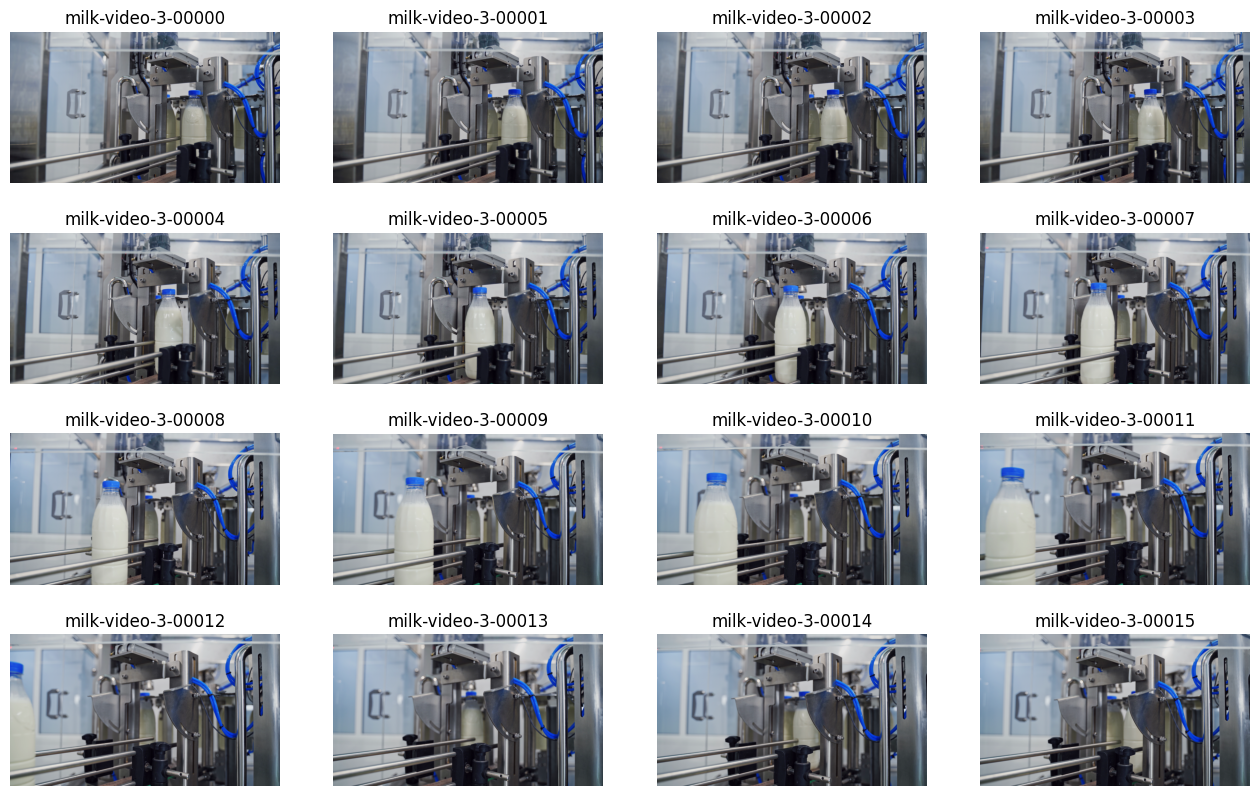

156 unlabeled images ready for auto-labeling.


In [9]:
# ── Cell 6: Display image sample ──────────────────────────────────────────────
import cv2
import supervision as sv

image_paths = sorted((DATA_DIR / "milk_images").glob("*.png"))

SAMPLE_SIZE = 16
SAMPLE_GRID = (4, 4)

titles = [p.stem for p in image_paths[:SAMPLE_SIZE]]
images = [cv2.imread(str(p)) for p in image_paths[:SAMPLE_SIZE]]

sv.plot_images_grid(images=images, titles=titles, grid_size=SAMPLE_GRID, size=(16, 10))
print(f"{len(image_paths)} unlabeled images ready for auto-labeling.")

---
## Step 2: Auto-Label with SAM3 (the Teacher)

**Ontology** maps text prompts to class names. This is all the teacher needs:

| Prompt (what SAM3 searches for) | Class name (what YOLO learns) | Class ID |
|:-------------------------------:|:-----------------------------:|:--------:|
|  |  | 0 |
|  |  | 1 |

No manual labeling. No annotation tool. Just two text prompts.

In [11]:
# ── Cell 8: Load SAM3 teacher + define ontology ──────────────────────────────
import numpy as np
from PIL import Image
from transformers import Sam3Model, Sam3Processor

MODEL_ID = "facebook/sam3"
hf_token = os.getenv("HF_TOKEN", None)

print(f"Loading {MODEL_ID} ...")
processor = Sam3Processor.from_pretrained(MODEL_ID, token=hf_token)
model = Sam3Model.from_pretrained(MODEL_ID, token=hf_token).to(DEVICE)

param_count = sum(p.numel() for p in model.parameters())
print(f"SAM3 loaded on {DEVICE} — {param_count / 1e9:.1f}B parameters")

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# Ontology: prompt → (class_name, class_id)
ONTOLOGY = {
    "milk bottle": ("bottle", 0),
    "blue cap":    ("cap",    1),
}

print(f"Ontology:")
for prompt, (name, cid) in ONTOLOGY.items():
    print(f"  {prompt} → {name} (class {cid})")

Loading facebook/sam3 ...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

SAM3 loaded on mps — 0.8B parameters
Ontology:
  milk bottle → bottle (class 0)
  blue cap → cap (class 1)


Image: milk-video-3-00000.png  (3840x2160)
milk bottle → 6 detections
blue cap → 2 detections


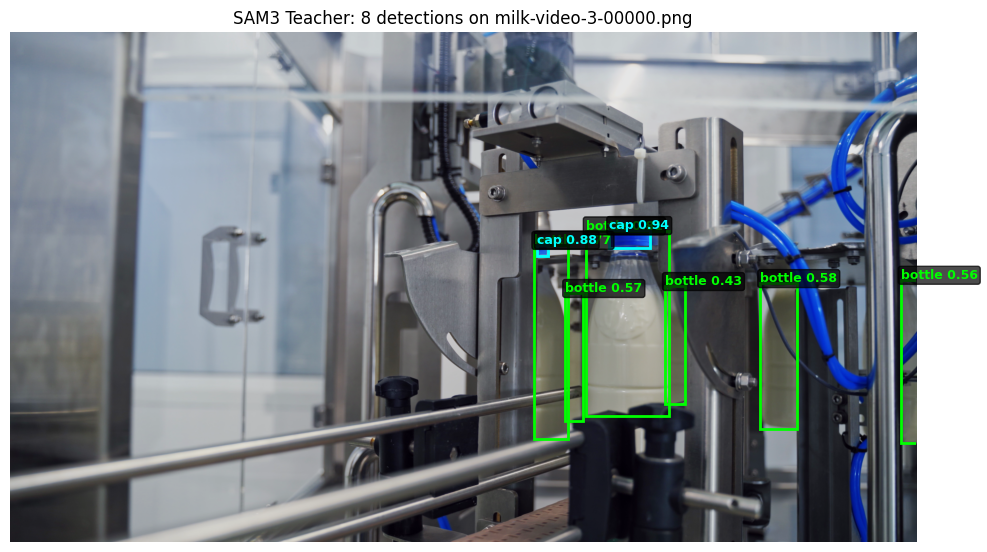

In [13]:
# ── Cell 9: Auto-label ONE image (demonstrate the concept) ───────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image_paths = sorted((DATA_DIR / "milk_images").glob("*.png"))
sample_path = image_paths[0]
img = Image.open(sample_path).convert("RGB")
img_w, img_h = img.size
print(f"Image: {sample_path.name}  ({img_w}x{img_h})")


def run_sam3_text(image, text, threshold=0.3):
    """Run SAM3 text-prompted detection on one image."""
    inputs = processor(images=image, text=text, return_tensors="pt").to(DEVICE)
    ctx = torch.autocast(device_type="cuda", dtype=torch.bfloat16) if DEVICE == "cuda" else torch.no_grad()
    with ctx, torch.no_grad():
        outputs = model(**inputs)
    target_sizes = inputs.get("original_sizes")
    if target_sizes is not None:
        target_sizes = target_sizes.tolist()
    else:
        target_sizes = [(image.size[1], image.size[0])]
    result = processor.post_process_instance_segmentation(
        outputs, threshold=threshold, mask_threshold=0.0, target_sizes=target_sizes,
    )[0]
    boxes = result.get("boxes", [])
    scores = result.get("scores", [])
    if hasattr(boxes, "tolist"): boxes = boxes.tolist()
    if hasattr(scores, "tolist"): scores = scores.tolist()
    return boxes, scores


# Run SAM3 for each prompt in the ontology
all_boxes, all_scores, all_classes, all_labels = [], [], [], []

for prompt, (class_name, class_id) in ONTOLOGY.items():
    boxes, scores = run_sam3_text(img, prompt)
    for box, score in zip(boxes, scores):
        all_boxes.append(box)
        all_scores.append(score)
        all_classes.append(class_id)
        all_labels.append(class_name)
    print(f"{prompt} → {len(boxes)} detections")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(np.array(img))
colors = {0: "lime", 1: "cyan"}
for box, score, cid, label in zip(all_boxes, all_scores, all_classes, all_labels):
    x1, y1, x2, y2 = box
    c = colors.get(cid, "yellow")
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=c, facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f"{label} {score:.2f}", color=c, fontsize=9,
            fontweight="bold", bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7))
ax.set_title(f"SAM3 Teacher: {len(all_boxes)} detections on {sample_path.name}", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 10: Auto-label ALL images → YOLO dataset ────────────────────────────
import yaml
import shutil

DATASET_DIR = DATA_DIR / "milk_dataset"
TRAIN_IMG_DIR = DATASET_DIR / "images" / "train"
TRAIN_LBL_DIR = DATASET_DIR / "labels" / "train"
VAL_IMG_DIR   = DATASET_DIR / "images" / "val"
VAL_LBL_DIR   = DATASET_DIR / "labels" / "val"

for d in [TRAIN_IMG_DIR, TRAIN_LBL_DIR, VAL_IMG_DIR, VAL_LBL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

image_paths = sorted((DATA_DIR / "milk_images").glob("*.png"))

# 80/20 train/val split
split_idx = int(len(image_paths) * 0.8)
train_paths = image_paths[:split_idx]
val_paths = image_paths[split_idx:]

# ── Cache check: skip SAM3 if labels already exist on disk ────────────────────
existing_train_lbls = list(TRAIN_LBL_DIR.glob("*.txt"))
existing_val_lbls = list(VAL_LBL_DIR.glob("*.txt"))
expected_train = len(train_paths)
expected_val = len(val_paths)

if len(existing_train_lbls) >= expected_train and len(existing_val_lbls) >= expected_val:
    print(f"Dataset already exists on disk — skipping SAM3 inference.")
    print(f"  Train: {len(existing_train_lbls)} labels (expected {expected_train})")
    print(f"  Val:   {len(existing_val_lbls)} labels (expected {expected_val})")
    print(f"  To force re-labeling, delete {DATASET_DIR / 'labels'} and re-run this cell.")
else:
    print(f"Auto-labeling {len(image_paths)} images ({len(train_paths)} train / {len(val_paths)} val)...")
    print(f"This runs SAM3 with {len(ONTOLOGY)} prompts per image.")

    for split_name, paths, img_dir, lbl_dir in [
        ("train", train_paths, TRAIN_IMG_DIR, TRAIN_LBL_DIR),
        ("val", val_paths, VAL_IMG_DIR, VAL_LBL_DIR),
    ]:
        for img_path in tqdm(paths, desc=f"Labeling {split_name}"):
            img = Image.open(img_path).convert("RGB")
            img_w, img_h = img.size
            yolo_lines = []

            for prompt, (class_name, class_id) in ONTOLOGY.items():
                boxes, scores = run_sam3_text(img, prompt, threshold=0.3)
                for box in boxes:
                    x1, y1, x2, y2 = box
                    cx = ((x1 + x2) / 2) / img_w
                    cy = ((y1 + y2) / 2) / img_h
                    w = (x2 - x1) / img_w
                    h = (y2 - y1) / img_h
                    # Skip degenerate boxes
                    if w > 0.01 and h > 0.01:
                        yolo_lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

            # Copy image and write label
            shutil.copy2(img_path, img_dir / img_path.name)
            label_path = lbl_dir / img_path.with_suffix(".txt").name
            label_path.write_text(
                "\n".join(yolo_lines) + ("\n" if yolo_lines else "")
            )

    print(f"Done! Labels written to {DATASET_DIR}")

# Write data.yaml (always — ensures it's up to date)
data_yaml = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "names": {0: "bottle", 1: "cap"},
    "nc": 2,
}
yaml_path = DATASET_DIR / "data.yaml"
yaml_path.write_text(yaml.dump(data_yaml, default_flow_style=False))
print(f"\ndata.yaml:")
print(yaml_path.read_text())

# Count labels
n_train = len(list(TRAIN_LBL_DIR.glob("*.txt")))
n_val = len(list(VAL_LBL_DIR.glob("*.txt")))
print(f"Train: {n_train} images  |  Val: {n_val} images")

In [ ]:
# ── Cell 11: Display labeled dataset sample ──────────────────────────────────
import supervision as sv

ANNOTATIONS_DIR = str(DATASET_DIR / "labels" / "train")
IMAGES_DIR_STR  = str(DATASET_DIR / "images" / "train")
DATA_YAML_PATH  = str(DATASET_DIR / "data.yaml")

dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=IMAGES_DIR_STR,
    annotations_directory_path=ANNOTATIONS_DIR,
    data_yaml_path=DATA_YAML_PATH,
)
print(f"Labeled dataset: {len(dataset)} images")

SAMPLE_SIZE = 16
box_ann = sv.BoxAnnotator()
lbl_ann = sv.LabelAnnotator(text_scale=0.4, text_padding=3)

images = []
titles = []
for i, (image_path, image, annotation) in enumerate(dataset):
    if i >= SAMPLE_SIZE:
        break
    annotated = box_ann.annotate(image.copy(), annotation)
    annotated = lbl_ann.annotate(annotated, annotation)
    images.append(annotated)
    titles.append(Path(image_path).stem)

sv.plot_images_grid(images=images, titles=titles, grid_size=(4, 4), size=(16, 10))

In [ ]:
# ── Cell 12: Show a sample label file ─────────────────────────────────────────
label_files = sorted((DATASET_DIR / "labels" / "train").glob("*.txt"))
if label_files:
    sample = label_files[0]
    content = sample.read_text()
    lines = content.strip().split("\n")
    print(f"Label file: {sample.name}")
    print("=" * 50)
    print(content)
    print(f"{len(lines)} objects labeled")
    print(f"Class 0 = bottle, Class 1 = cap")
    print(f"Format: class_id  center_x  center_y  width  height  (all normalized 0-1)")
    print(f"This is identical to what a human annotator would produce.")

---
## Step 3: Train the Student (YOLO26n)

The student model has never seen the teacher. It only sees:
- The images
- The  label files

From the student's perspective, these labels are indistinguishable from human annotations.
Same format. Same coordinate system.

In [ ]:
# ── Cell 14: Train YOLO26n student ────────────────────────────────────────────
from ultralytics import YOLO

student = YOLO("yolo26n.pt")  # 2.4M parameters, pre-trained on COCO

print("Training YOLO26n on auto-labeled milk bottle dataset...")
print(f"Dataset: {DATASET_DIR / 'data.yaml'}")

# Single training run — 50 epochs, matching the reference notebook
results = student.train(
    data=str(DATASET_DIR / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    device=DEVICE if DEVICE != "mps" else "mps",
    workers=4 if DEVICE == "cuda" else 0,
    verbose=True,
)

In [ ]:
# ── Cell 15: Evaluate — confusion matrix + results ───────────────────────────
from IPython.display import display, Image as IPImage
from pathlib import Path
import glob

# Find the latest training run
runs = sorted(glob.glob(str(HOME / "runs" / "detect" / "train*")))
run_dir = Path(runs[-1]) if runs else HOME / "runs" / "detect" / "train"

print(f"Training artifacts: {run_dir}")

# Confusion matrix
cm_path = run_dir / "confusion_matrix.png"
if cm_path.exists():
    display(IPImage(filename=str(cm_path), width=600))
else:
    print(f"Confusion matrix not found at {cm_path}")

# Results plot
results_path = run_dir / "results.png"
if results_path.exists():
    display(IPImage(filename=str(results_path), width=700))
else:
    print(f"Results plot not found at {results_path}")

# Validation predictions
val_pred_path = run_dir / "val_batch0_pred.jpg"
if val_pred_path.exists():
    display(IPImage(filename=str(val_pred_path), width=700))
    print("Validation predictions — these detections came from the STUDENT model.")
else:
    print(f"Val predictions not found at {val_pred_path}")

---
## Step 4: Speed Comparison — Teacher vs Student

The whole point of distillation: the student must be **fast enough to deploy**.
Let's measure the actual speed difference.

In [ ]:
# ── Cell 17: Teacher vs Student speed comparison ─────────────────────────────
import matplotlib.pyplot as plt

test_img_path = sorted((DATASET_DIR / "images" / "val").glob("*.png"))[0]
test_img = Image.open(test_img_path).convert("RGB")
N_RUNS = 5

# ---- Teacher (SAM3) ----
warmup_inputs = processor(images=test_img, text="milk bottle", return_tensors="pt").to(DEVICE)
with torch.no_grad():
    _ = model(**warmup_inputs)

teacher_times = []
for _ in range(N_RUNS):
    inp = processor(images=test_img, text="milk bottle", return_tensors="pt").to(DEVICE)
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(**inp)
    if DEVICE == "cuda": torch.cuda.synchronize()
    teacher_times.append((time.perf_counter() - t0) * 1000)

avg_teacher = sum(teacher_times) / len(teacher_times)
print(f"Teacher (SAM3):   {avg_teacher:.1f} ms  ({1000/avg_teacher:.0f} FPS)")

# ---- Student (YOLO26n) ----
runs = sorted(glob.glob(str(HOME / "runs" / "detect" / "train*")))
best_pt = Path(runs[-1]) / "weights" / "best.pt" if runs else None

if best_pt and best_pt.exists():
    trained_student = YOLO(str(best_pt))
else:
    trained_student = YOLO("yolo26n.pt")
    print("(Using base YOLO26n — trained weights not found)")

_ = trained_student(str(test_img_path), verbose=False)  # warmup

student_times = []
for _ in range(N_RUNS):
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = trained_student(str(test_img_path), verbose=False)
    if DEVICE == "cuda": torch.cuda.synchronize()
    student_times.append((time.perf_counter() - t0) * 1000)

avg_student = sum(student_times) / len(student_times)
print(f"Student (YOLO26n): {avg_student:.1f} ms  ({1000/avg_student:.0f} FPS)")
print(f"Speedup: {avg_teacher / avg_student:.0f}x faster")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(["SAM3 (Teacher)", "YOLO26n (Student)"],
               [avg_teacher, avg_student],
               color=["#e74c3c", "#27ae60"], height=0.5)
ax.set_xlabel("Inference Time (ms)")
ax.set_title(f"Speed: {avg_teacher/avg_student:.0f}x speedup ({DEVICE.upper()})", fontsize=12)
for bar, t in zip(bars, [avg_teacher, avg_student]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{t:.1f} ms", va="center", fontsize=11, fontweight="bold")
ax.set_xlim(0, max(avg_teacher, avg_student) * 1.3)
plt.tight_layout()
plt.show()

---
## Step 5: How Much Data Does the Student Need?

We have ~124 labeled training images. But do we need all of them?

This experiment trains **5 separate YOLO26n models** on progressively larger subsets
of the auto-labeled data (20%, 40%, 60%, 80%, 100%). The validation set stays fixed
across all runs so the comparison is fair.

The question: **does more data always help, or do we hit a ceiling?**

In [ ]:
# ── Cell 19: Scaling experiment — 5 training runs with progressive data ───────
import shutil
import yaml
import json
from ultralytics import YOLO

FRACTIONS = [0.2, 0.4, 0.6, 0.8, 1.0]
SCALE_EPOCHS = 30
SCALING_DIR = DATA_DIR / "scaling_experiment"
SCALING_DIR.mkdir(exist_ok=True)

# Source: the full auto-labeled dataset from cell 10
all_train_imgs = sorted(TRAIN_IMG_DIR.glob("*.png"))
all_train_lbls = {p.stem: p for p in sorted(TRAIN_LBL_DIR.glob("*.txt"))}
n_total = len(all_train_imgs)

print(f"Full training set: {n_total} images")
print(f"Validation set: {len(list(VAL_IMG_DIR.glob('*.png')))} images (fixed across all runs)")
print(f"Running {len(FRACTIONS)} experiments × {SCALE_EPOCHS} epochs each\n")

scaling_results = []

for frac in FRACTIONS:
    n_subset = max(5, int(n_total * frac))
    run_name = f"scale_{int(frac * 100):03d}pct"
    subset_dir = SCALING_DIR / run_name

    # Create subset dataset directories
    sub_img_train = subset_dir / "images" / "train"
    sub_lbl_train = subset_dir / "labels" / "train"
    sub_img_val   = subset_dir / "images" / "val"
    sub_lbl_val   = subset_dir / "labels" / "val"
    for d in [sub_img_train, sub_lbl_train, sub_img_val, sub_lbl_val]:
        d.mkdir(parents=True, exist_ok=True)

    # Copy subset of training images + labels
    for img_path in all_train_imgs[:n_subset]:
        shutil.copy2(img_path, sub_img_train / img_path.name)
        lbl_path = all_train_lbls.get(img_path.stem)
        if lbl_path and lbl_path.exists():
            shutil.copy2(lbl_path, sub_lbl_train / lbl_path.name)

    # Copy FULL val set (same for every run — fair comparison)
    for img_path in sorted(VAL_IMG_DIR.glob("*.png")):
        shutil.copy2(img_path, sub_img_val / img_path.name)
        lbl_name = img_path.with_suffix(".txt").name
        lbl_path = VAL_LBL_DIR / lbl_name
        if lbl_path.exists():
            shutil.copy2(lbl_path, sub_lbl_val / lbl_name)

    # Write data.yaml for this subset
    data_cfg = {
        "path": str(subset_dir),
        "train": "images/train",
        "val": "images/val",
        "names": {0: "bottle", 1: "cap"},
        "nc": 2,
    }
    yaml_path = subset_dir / "data.yaml"
    yaml_path.write_text(yaml.dump(data_cfg, default_flow_style=False))

    # Train
    print(f"{'='*60}")
    print(f"[{FRACTIONS.index(frac)+1}/{len(FRACTIONS)}] Training with {n_subset}/{n_total} images ({frac*100:.0f}%)")
    print(f"{'='*60}")

    student = YOLO("yolo26n.pt")
    train_results = student.train(
        data=str(yaml_path),
        epochs=SCALE_EPOCHS,
        imgsz=640,
        batch=16,
        device=DEVICE if DEVICE != "mps" else "mps",
        workers=4 if DEVICE == "cuda" else 0,
        verbose=False,
        project=str(SCALING_DIR / "runs"),
        name=run_name,
    )

    # Extract final validation mAP50
    metrics = train_results.results_dict if hasattr(train_results, "results_dict") else {}
    map50 = metrics.get("metrics/mAP50(B)", 0.0)
    map50_95 = metrics.get("metrics/mAP50-95(B)", 0.0)

    scaling_results.append({
        "fraction": frac,
        "n_images": n_subset,
        "map50": round(map50, 4),
        "map50_95": round(map50_95, 4),
    })
    print(f"  → mAP50 = {map50:.3f}   mAP50-95 = {map50_95:.3f}\n")

# Save results to JSON for reproducibility
results_path = SCALING_DIR / "scaling_results.json"
results_path.write_text(json.dumps(scaling_results, indent=2))
print(f"\nResults saved to {results_path}")

# Print summary table
print(f"\n{'Images':>8} {'Fraction':>10} {'mAP50':>8} {'mAP50-95':>10}")
print(f"{'-'*40}")
for r in scaling_results:
    print(f"{r['n_images']:>8} {r['fraction']*100:>9.0f}% {r['map50']:>8.3f} {r['map50_95']:>10.3f}")

In [ ]:
# ── Cell 20: Plot scaling curve + fitted extrapolation ────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.optimize import curve_fit

# Load results (from cell 19 or from saved JSON)
results_path = SCALING_DIR / "scaling_results.json"
if results_path.exists():
    scaling_results = json.loads(results_path.read_text())

n_images = np.array([r["n_images"] for r in scaling_results])
map50_vals = np.array([r["map50"] for r in scaling_results])
map50_95_vals = np.array([r["map50_95"] for r in scaling_results])

# ── Fit saturating exponential: f(x) = a * (1 - exp(-b * x)) ─────────────────
def saturating_exp(x, a, b):
    return a * (1 - np.exp(-b * x))

try:
    popt, pcov = curve_fit(saturating_exp, n_images, map50_vals, p0=[0.9, 0.02], maxfev=5000)
    a_fit, b_fit = popt
    fit_ok = True
except RuntimeError:
    fit_ok = False
    print("Warning: curve fitting did not converge. Showing raw data only.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

if fit_ok:
    # Extrapolate curve well beyond our data
    x_extrap = np.linspace(0, max(n_images) * 4, 500)
    y_extrap = saturating_exp(x_extrap, a_fit, b_fit)

    ax.plot(x_extrap, y_extrap, "--", color="#95a5a6", linewidth=2,
            label=f"Fit: {a_fit:.2f} × (1 − e^(−{b_fit:.4f}x))")

    # Asymptote line
    ax.axhline(y=a_fit, color="#e74c3c", linestyle=":", alpha=0.6,
               label=f"Asymptote = {a_fit:.3f}")

    # Target: 0.85 mAP50
    TARGET = 0.85
    if a_fit > TARGET:
        # Solve: TARGET = a * (1 - exp(-b * x))  →  x = -ln(1 - TARGET/a) / b
        n_needed = -np.log(1 - TARGET / a_fit) / b_fit
        ax.axhline(y=TARGET, color="#27ae60", linestyle="-.", alpha=0.6,
                   label=f"Target mAP50 = {TARGET}")
        ax.axvline(x=n_needed, color="#27ae60", linestyle="-.", alpha=0.4)
        ax.scatter([n_needed], [TARGET], s=150, color="#27ae60", marker="*", zorder=6)
        ax.annotate(f"~{int(np.ceil(n_needed))} images\nfor mAP50 ≥ {TARGET}",
                   (n_needed, TARGET), textcoords="offset points",
                   xytext=(15, -25), ha="left", fontsize=11, fontweight="bold",
                   color="#27ae60", arrowprops=dict(arrowstyle="->", color="#27ae60"))
    else:
        n_needed = None
        ax.text(0.5, 0.95, f"Asymptote ({a_fit:.3f}) is below {TARGET} — more data alone won't reach it.\nBetter labels or prompts needed.",
               transform=ax.transAxes, ha="center", va="top", fontsize=11,
               color="#e74c3c", fontweight="bold",
               bbox=dict(boxstyle="round,pad=0.4", facecolor="#ffeaea"))

# Data points
ax.plot(n_images, map50_vals, "o-", color="#3498db", linewidth=2, markersize=10,
        label="mAP50 (measured)", zorder=5)
for x, y in zip(n_images, map50_vals):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
               xytext=(0, 14), ha="center", fontsize=10, fontweight="bold", color="#3498db")

ax.plot(n_images, map50_95_vals, "s--", color="#e67e22", linewidth=2, markersize=8,
        label="mAP50-95 (measured)", zorder=5)
for x, y in zip(n_images, map50_95_vals):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
               xytext=(0, -18), ha="center", fontsize=9, color="#e67e22")

ax.set_xlabel("Number of Training Images", fontsize=12)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("Data Scaling: How Much Data Does the Student Need?",
            fontsize=13, fontweight="bold")
x_max = max(n_images) * 1.1 if not fit_ok else max(max(n_images) * 1.5, n_needed * 1.2 if (fit_ok and n_needed) else 0)
ax.set_xlim(0, max(x_max, max(n_images) * 1.5))
ax.set_ylim(0, 1.0)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
if fit_ok:
    print(f"\nFitted curve: mAP50 = {a_fit:.3f} × (1 − e^(−{b_fit:.4f} × n))")
    print(f"Asymptote: {a_fit:.3f} (theoretical max with current labels)")
    if n_needed and a_fit > TARGET:
        print(f"Prediction: ~{int(np.ceil(n_needed))} images needed for mAP50 ≥ {TARGET}")
        print(f"  That's {int(np.ceil(n_needed)) - int(max(n_images))} more images beyond our current {int(max(n_images))}.")
    else:
        print(f"\nThe asymptote ({a_fit:.3f}) is BELOW {TARGET}.")
        print(f"More data won't get you there — you need better labels (prompt engineering).")
        print(f"This is exactly the lesson from Day 2.")

---
## Tomorrow: Make It Yours

**Day 2 (16:00-18:00)**

You will:
1. Choose YOUR detection problem
2. Auto-label YOUR images with SAM3
3. See where the teacher fails — error analysis is the real skill
4. Distill to YOLO26n — YOUR model, YOUR classes
5. Compare: does YOUR model fit YOUR deployment target?

**What to think about tonight:**
- What do you want to detect?
- Where will the model run? (cloud, edge, mobile)
- What is your FPS requirement?
- Does licensing matter for your use case?

---

## Key Takeaways

1. **Distillation pipeline**: Large teacher auto-labels images → small student trains on those labels → teacher retires, student deploys.

2. **Speed matters**: YOLO26n is orders of magnitude faster than SAM3. On edge hardware, that's the difference between real-time and impossible.

3. **Data scaling**: More data helps — up to a point. The scaling curve shows where diminishing returns kick in for this domain.

4. **Zero human annotations**: Every label in this pipeline was generated by a machine — and it works.

5. **The pipeline is domain-agnostic**: We showed milk bottles today. Tomorrow you plug in your own prompts and images.